# Box Plots in Seaborn

A **Box Plot** (Box-and-Whisker Plot) displays the distribution of numerical data based on the **Five-Number Summary**:
1. Minimum (excluding outliers)
2. First Quartile (Q1 / 25th percentile)
3. Median (Q2 / 50th percentile)
4. Third Quartile (Q3 / 75th percentile)
5. Maximum (excluding outliers)

Data points positioned beyond $1.5 \times IQR$ from the quartiles are marked as **outliers**.


In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

data_path = os.path.join("datasets", "tips.csv")
if os.path.exists(data_path):
    tips = pd.read_csv(data_path)
else:
    tips = sns.load_dataset("tips")

tips.head()


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


## 1. Single Variable and Categorical Box Plot


C:\Users\sanja\AppData\Local\Temp\ipykernel_16756\2362067110.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=tips, x="day", y="total_bill", palette="Blues", width=0.5)


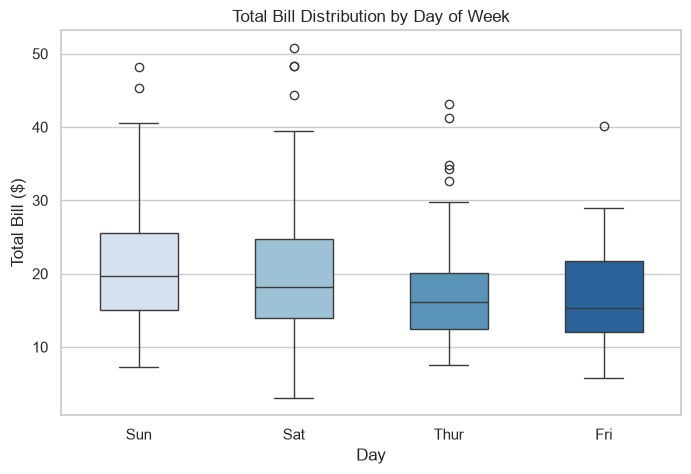

In [2]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=tips, x="day", y="total_bill", palette="Blues", width=0.5)
plt.title("Total Bill Distribution by Day of Week")
plt.xlabel("Day")
plt.ylabel("Total Bill ($)")
plt.show()


## 2. Grouped Boxplot with Hue
Compare total bill spread for smokers vs non-smokers across each day.


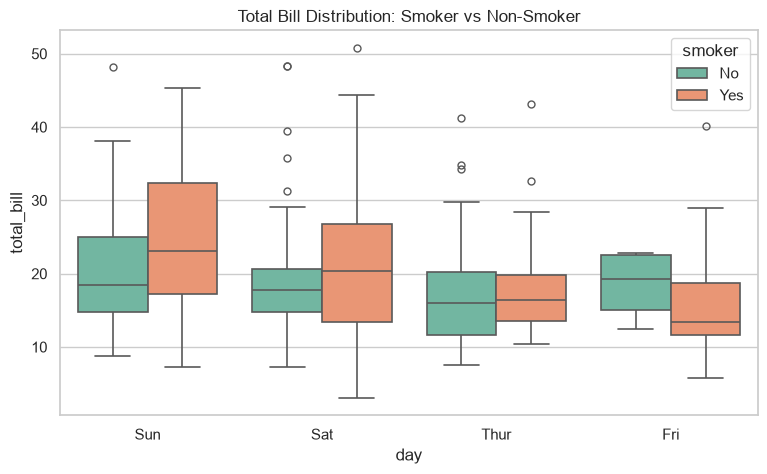

In [3]:
plt.figure(figsize=(9, 5))
sns.boxplot(
    data=tips,
    x="day",
    y="total_bill",
    hue="smoker",
    palette="Set2",
    fliersize=5,
    linewidth=1.2
)
plt.title("Total Bill Distribution: Smoker vs Non-Smoker")
plt.show()


## 3. Mathematical 5-Number Summary and IQR Calculation


In [4]:
sun_bills = tips[tips["day"] == "Sun"]["total_bill"]
q1 = sun_bills.quantile(0.25)
q3 = sun_bills.quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr
outliers = sun_bills[(sun_bills < lower_bound) | (sun_bills > upper_bound)]

print(f"Sunday Total Bill IQR Analysis:")
print(f"  Q1 (25th percentile): ${q1:.2f}")
print(f"  Median (50th):        ${sun_bills.median():.2f}")
print(f"  Q3 (75th percentile): ${q3:.2f}")
print(f"  IQR:                  ${iqr:.2f}")
print(f"  Lower Whisker Limit:  ${lower_bound:.2f}")
print(f"  Upper Whisker Limit:  ${upper_bound:.2f}")
print(f"  Detected Outliers count: {len(outliers)}")


Sunday Total Bill IQR Analysis:
  Q1 (25th percentile): $14.99
  Median (50th):        $19.63
  Q3 (75th percentile): $25.60
  IQR:                  $10.61
  Lower Whisker Limit:  $-0.93
  Upper Whisker Limit:  $41.51
  Detected Outliers count: 2
